In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil
import re
import seaborn as sns
from itertools import combinations
import numpy as np
import xgboost
import lightgbm
#import tensorflow as tf
from pymatgen.core.structure import Structure
import ast
import time

/home/parastoo/anaconda3/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [153]:
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', 2000)

In [3]:
# Neighbor‑sweep + 15 models with your desired splitting logic
import re
import time
import warnings
import numpy as np
import pandas as pd
from typing import List, Optional, Dict, Tuple

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning

# Optional: XGBoost, TabPFN
try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False

try:
    from tabpfn import TabPFNRegressor
    _HAS_TABPFN = True
except ImportError:
    _HAS_TABPFN = False


# ========== Config Defaults ==========
TARGET = "ads_e"
NEIGHBOR_FEATURES: List[str] = [
    "elect_affinity",
    "atomic_radius",
    "cov_rad",
    "atom_density",
    "charge",
    "electroneg",
]

DOS_PREFIX = "n0_n{end}_dos_{sel}_"
DIST_SUFFIX = "distance"


# ========== Helpers ==========

def _rmse(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))


def _plain_neighbor_means_window(
    df: pd.DataFrame, start: int, end: int, features: List[str]
) -> pd.DataFrame:
    """Average across n{start}_feat .. n{end}_feat (inclusive)."""
    out: Dict[str, pd.Series] = {}
    for feat in features:
        cols = [f"n{i}_{feat}" for i in range(start, end + 1) if f"n{i}_{feat}" in df.columns]
        if cols:
            out[f"avg_{feat}_n{start}_n{end}"] = df[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
    return pd.DataFrame(out, index=df.index)


def _weighted_neighbor_means_window(
    df: pd.DataFrame,
    start: int,
    end: int,
    features: List[str],
    dist_suffix: str = DIST_SUFFIX,
    weight_power: float = 1.0,
    eps: float = 1e-12,
) -> pd.DataFrame:
    """Distance-weighted averages over neighbors in [start, end]."""
    out: Dict[str, pd.Series] = {}
    for feat in features:
        feat_cols, dist_cols = [], []
        for i in range(start, end + 1):
            fcol = f"n{i}_{feat}"
            dcol = f"n{i}_{dist_suffix}"
            if (fcol in df.columns) and (dcol in df.columns):
                feat_cols.append(fcol)
                dist_cols.append(dcol)
        if not feat_cols:
            continue
        V = df[feat_cols].apply(pd.to_numeric, errors="coerce")
        D = df[dist_cols].apply(pd.to_numeric, errors="coerce").abs()
        valid = D.where(D > eps)
        W = 1.0 / (valid ** weight_power)
        num = (V * W).sum(axis=1, skipna=True)
        den = W.sum(axis=1, skipna=True)
        out[f"wavg_{feat}_n{start}_n{end}"] = num / den
    return pd.DataFrame(out, index=df.index)


def _pick_dos_block_window(
    df: pd.DataFrame,
    start: int,
    end: int,
    bands: Optional[List[str]] = None,
    stats: Optional[List[str]] = None,
    dos_selection: Optional[List[str]] = None,
) -> pd.DataFrame:
    """Pick DOS columns for window n{start}..n{end}."""
    if bands is None:
        bands = ["s", "p", "d"]
    if stats is None:
        stats = ["sum", "center"]
    if dos_selection is None:
        selections = {"selected"}
    else:
        selections = {s for s in dos_selection if s in {"selected", "total"}}
        if not selections:
            return pd.DataFrame(index=df.index)
    bands = [b for b in bands if b in {"s", "p", "d"}]
    stats = [s for s in stats if s in {"sum", "center"}]
    if not bands or not stats:
        return pd.DataFrame(index=df.index)

    wanted = set()
    for sel in selections:
        pref = DOS_PREFIX.format(end=end, sel=sel)
        for b in bands:
            for s in stats:
                wanted.add(pref + f"{b}band_{s}")

    cols = [c for c in df.columns if (c in wanted) and (not c.endswith("indices"))]
    if not cols:
        return pd.DataFrame(index=df.index)
    return df[cols].apply(pd.to_numeric, errors="coerce")


def build_X_for_window(
    df: pd.DataFrame,
    start: int,
    end: int,
    features: List[str],
    weighted: bool = False,
    weight_power: float = 1.0,
    distance_suffix: str = DIST_SUFFIX,
    add_feature: Optional[str] = None,
    use_dos: bool = True,
    dos_bands: Optional[List[str]] = None,
    dos_stats: Optional[List[str]] = None,
    dos_selection: Optional[List[str]] = None
) -> pd.DataFrame:
    """Build features X for the neighbor window [start, end]."""
    parts = []
    if weighted:
        block = _weighted_neighbor_means_window(df, start, end, features, dist_suffix=distance_suffix, weight_power=weight_power)
    else:
        block = _plain_neighbor_means_window(df, start, end, features)
    if not block.empty:
        parts.append(block)

    if use_dos:
        dos_block = _pick_dos_block_window(df, start, end, bands=dos_bands, stats=dos_stats, dos_selection=dos_selection)
        if not dos_block.empty:
            parts.append(dos_block)

    if add_feature and add_feature in df.columns:
        parts.append(pd.to_numeric(df[[add_feature]], errors="coerce").rename(columns={add_feature: add_feature}))

    if not parts:
        return pd.DataFrame(index=df.index)
    return pd.concat(parts, axis=1)


def model_zoo(random_state: int = 42) -> Dict[str, Pipeline]:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    def make_scaled(est):
        return Pipeline([("imputer", imputer), ("scaler", scaler), ("model", est)])

    def make_unscaled(est):
        return Pipeline([("imputer", imputer), ("model", est)])

    models: Dict[str, Pipeline] = {
        "LinearRegression": make_scaled(LinearRegression()),
        "Ridge": make_scaled(Ridge(random_state=random_state)),
        "Lasso": make_scaled(Lasso(max_iter=5000, random_state=random_state)),
        "ElasticNet": make_scaled(ElasticNet(max_iter=5000, random_state=random_state)),
        "HuberRegressor": make_scaled(HuberRegressor(max_iter=5000)),
        "DecisionTreeRegressor": make_unscaled(DecisionTreeRegressor(random_state=random_state)),
        "RandomForestRegressor": make_unscaled(RandomForestRegressor(n_estimators=300, random_state=random_state, n_jobs=-1)),
        "GradientBoostingRegressor": make_unscaled(GradientBoostingRegressor(random_state=random_state)),
        "ExtraTreesRegressor": make_unscaled(ExtraTreesRegressor(n_estimators=400, random_state=random_state, n_jobs=-1)),
        "SVR": make_scaled(SVR(kernel="rbf", C=10.0, gamma="scale")),
        "KernelRidge": make_scaled(KernelRidge(kernel="rbf", alpha=1.0, gamma=None)),
        "KNeighborsRegressor": make_scaled(KNeighborsRegressor(n_neighbors=7, weights="distance")),
        "MLPRegressor": make_scaled(MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            learning_rate_init=1e-3,
            max_iter=2000,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=random_state,
            verbose=False
        )),
    }

    if _HAS_TABPFN:
        models["TabPFNRegressor"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", TabPFNRegressor())
        ])

    if _HAS_XGB:
        models["XGBRegressor"] = make_unscaled(XGBRegressor(random_state=random_state))

    return models


def fit_eval_model(pipe: Pipeline, X_train, X_eval, y_train, y_eval) -> Dict[str, float]:
    """Fit on train, evaluate on eval (val) set."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_eval)
    return {
        "r2": r2_score(y_eval, y_pred),
        "rmse": _rmse(y_eval, y_pred),
        "mae": mean_absolute_error(y_eval, y_pred),
        "y_pred": y_pred,
    }


def run_neighbor_sweep_models(
    df: pd.DataFrame,
    df_name: str = "dataset",
    n_min: int = 0,
    n_max: Optional[int] = None,
    test_size: float = 0.2,
    val_size: float=0.15,
    random_state: int = 42,
    weighted: bool = False,
    weight_power: float = 1.0,
    features: Optional[List[str]] = None,
    distance_suffix: str = DIST_SUFFIX,
    target: str = TARGET,
    add_feature: Optional[str] = None,
    use_dos: bool = True,
    dos_bands: Optional[List[str]] = None,
    dos_stats: Optional[List[str]] = None,
    dos_selection: Optional[List[str]] = None
) -> Dict[str, object]:
    """
    Returns a dict containing:
      - 'split': (X_train, X_val, X_test, y_train, y_val, y_test)
      - 'val_results': nested dict: val_results[n][model_name] => metrics on val
      - 'best_on_val': (best_n, best_model_name, best_val_metrics)
      - 'final_test': test performance of the globally selected model
      - 'best_pipeline': the retrained pipeline on train+val
      - 'all_pipelines': dict of pipelines retrained on train+val for each (n,model) if desired
    """

    if features is None:
        features = NEIGHBOR_FEATURES.copy()
    if n_max is None:
        raise ValueError("Please specify n_max.")
    start, end_max = int(n_min), int(n_max)
    if end_max < start:
        raise ValueError("n_max must be >= n_min")

    print(f"[run] df='{df_name}' target='{target}'")

    # First, do the global train/val/test split ONCE
    y_all = pd.to_numeric(df[target], errors="coerce")
    data_full = df.copy()
    data_full[target] = y_all

    data_full = data_full.dropna(subset=[target])
    # Split into train_val vs test
    train_val_df, test_df = train_test_split(data_full, test_size=test_size, random_state=random_state)
    # Then split train_val into train vs val
    train_df, val_df = train_test_split(train_val_df, test_size=val_size, random_state=random_state)

    # Extract y and X for each
    # We'll build features separately for each n
    val_results: Dict[int, Dict[str, Dict[str, float]]] = {}
    all_pipelines: Dict[Tuple[int, str], Pipeline] = {}

    models = model_zoo(random_state=random_state)

    # For each n, train on train_df, evaluate on val_df
    for end in range(start, end_max + 1):
        print(f" === n = {end} ===")
        # Build X_train_n, X_val_n
        X_train_n = build_X_for_window(
            train_df, start, end, features,
            weighted=weighted, weight_power=weight_power,
            distance_suffix=distance_suffix,
            add_feature=add_feature,
            use_dos=use_dos,
            dos_bands=dos_bands,
            dos_stats=dos_stats,
            dos_selection=dos_selection
        ).dropna(axis=1, how="all")

        X_val_n = build_X_for_window(
            val_df, start, end, features,
            weighted=weighted, weight_power=weight_power,
            distance_suffix=distance_suffix,
            add_feature=add_feature,
            use_dos=use_dos,
            dos_bands=dos_bands,
            dos_stats=dos_stats,
            dos_selection=dos_selection
        ).dropna(axis=1, how="all")

        # Align columns (keep only shared columns)
        shared_cols = X_train_n.columns.intersection(X_val_n.columns)
        X_train_n = X_train_n[shared_cols]
        X_val_n = X_val_n[shared_cols]

        y_train = pd.to_numeric(train_df[target], errors="coerce").loc[X_train_n.index]
        y_val = pd.to_numeric(val_df[target], errors="coerce").loc[X_val_n.index]

        val_results[end] = {}

        for name, pipe in models.items():
            try:
                # Fit on train, eval on val
                metrics = fit_eval_model(pipe, X_train_n, X_val_n, y_train, y_val)
                val_results[end][name] = metrics
                print(f"  {name}: val_r2={metrics['r2']:.4f} mae={metrics['mae']:.4f}")
            except Exception as e:
                val_results[end][name] = {"error": str(e)}
                print(f"  {name}: ERROR {e}")

    # After sweeping all n, pick the best on **val**
    best_n = None
    best_model_name = None
    best_val_r2 = -np.inf
    best_val_mae = np.inf

    for n, mres in val_results.items():
        for name, m in mres.items():
            if "r2" in m:
                r2v = m["r2"]
                maev = m["mae"]
                # Primary: maximize R2, secondary: minimize MAE
                if (r2v > best_val_r2) or (
                    (abs(r2v - best_val_r2) < 1e-6 and maev < best_val_mae)
                ):
                    best_n = n
                    best_model_name = name
                    best_val_r2 = r2v
                    best_val_mae = maev

    print(f"\n==> Best on val: n={best_n}, model={best_model_name}, val_r2={best_val_r2:.4f}, val_mae={best_val_mae:.4f}")

    # Retrain that best model on train + val, then test on test set
    train_val_union = pd.concat([train_df, val_df], axis=0)
    # Build feature matrices for train_val_union and test using the best_n
    X_trainval_best = build_X_for_window(
        train_val_union, start, best_n, features,
        weighted=weighted, weight_power=weight_power,
        distance_suffix=distance_suffix,
        add_feature=add_feature,
        use_dos=use_dos,
        dos_bands=dos_bands,
        dos_stats=dos_stats,
        dos_selection=dos_selection
    ).dropna(axis=1, how="all")

    X_test_best = build_X_for_window(
        test_df, start, best_n, features,
        weighted=weighted, weight_power=weight_power,
        distance_suffix=distance_suffix,
        add_feature=add_feature,
        use_dos=use_dos,
        dos_bands=dos_bands,
        dos_stats=dos_stats,
        dos_selection=dos_selection
    ).dropna(axis=1, how="all")

    shared_cols2 = X_trainval_best.columns.intersection(X_test_best.columns)
    X_trainval_best = X_trainval_best[shared_cols2]
    X_test_best = X_test_best[shared_cols2]

    y_trainval = pd.to_numeric(train_val_union[target], errors="coerce").loc[X_trainval_best.index]
    y_test = pd.to_numeric(test_df[target], errors="coerce").loc[X_test_best.index]

    # Instantiate a fresh pipeline for the best model
    best_pipe = model_zoo(random_state=random_state)[best_model_name]
    best_pipe.fit(X_trainval_best, y_trainval)
    y_test_pred = best_pipe.predict(X_test_best)
    test_metrics = {
        "r2": r2_score(y_test, y_test_pred),
        "rmse": _rmse(y_test, y_test_pred),
        "mae": mean_absolute_error(y_test, y_test_pred),
    }

    print(f"\n*** Final test results for best model: {test_metrics}")

    return {
        "split": (train_df, val_df, test_df),
        "val_results": val_results,
        "best_on_val": (best_n, best_model_name, {"r2": best_val_r2, "mae": best_val_mae}),
        "best_pipeline": best_pipe,
        "final_test": test_metrics,
        "config": {
            "features": features,
            "weighted": weighted,
            "weight_power": weight_power,
            "use_dos": use_dos,
            "dos_bands": dos_bands,
            "dos_stats": dos_stats,
            "dos_selection": dos_selection,
            "target": target,
        }
    }


# ========== Leaderboard / Display ==========
def summarize_val_results(val_results: Dict[int, Dict[str, Dict[str, float]]], top_k: int = 5) -> pd.DataFrame:
    """Flatten val_results into a DataFrame sorted by r2 descending per n."""
    rows = []
    for n, m in val_results.items():
        for name, metrics in m.items():
            if "r2" in metrics:
                rows.append({
                    "n": n,
                    "model": name,
                    "val_r2": metrics["r2"],
                    "val_rmse": metrics["rmse"],
                    "val_mae": metrics["mae"],
                })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["n", "val_r2"], ascending=[True, False]).groupby("n").head(top_k).reset_index(drop=True)


In [4]:
import pickle
import os

# Reconstruct the same dictionary of names you saved
names = [
    "res_N2", "res_N2H", "res_H2", "res_NH3",
    "res_N2_noOutlier", "res_N2H_noOutlier", "res_NH3_noOutlier", "res_H2_noOutlier",
    "tuned_res_N2", "tuned_res_N2H", "tuned_res_H2", "tuned_res_NH3",
    "tuned_res_N2_noOutlier", "tuned_res_N2H_noOutlier", "tuned_res_NH3_noOutlier", "tuned_res_H2_noOutlier"
]

loaded_results = {}

for name in names:
    path = f"./temp_files_/adsorbedOnly_{name}_v2.pkl"
    with open(path, "rb") as f:
        loaded_results[name] = pickle.load(f)
    print(f"Loaded {name} from {path}")

# Untuned
res_N2 = loaded_results["res_N2"]
res_N2H = loaded_results["res_N2H"]
res_H2 = loaded_results["res_H2"]
res_NH3 = loaded_results["res_NH3"]

# Untuned no Outlier
res_N2_noOutlier = loaded_results["res_N2_noOutlier"]
res_N2H_noOutlier = loaded_results["res_N2H_noOutlier"]
res_NH3_noOutlier = loaded_results["res_NH3_noOutlier"]
res_H2_noOutlier = loaded_results["res_H2_noOutlier"]

# Tuned
tuned_res_N2 = loaded_results["tuned_res_N2"]
tuned_res_N2H = loaded_results["tuned_res_N2H"]
tuned_res_H2 = loaded_results["tuned_res_H2"]
tuned_res_NH3 = loaded_results["tuned_res_NH3"]

# Tuned no Outlier
tuned_res_N2_noOutlier = loaded_results["tuned_res_N2_noOutlier"]
tuned_res_N2H_noOutlier = loaded_results["tuned_res_N2H_noOutlier"]
tuned_res_NH3_noOutlier = loaded_results["tuned_res_NH3_noOutlier"]
tuned_res_H2_noOutlier = loaded_results["tuned_res_H2_noOutlier"]



Loaded res_N2 from ./temp_files_/adsorbedOnly_res_N2_v2.pkl
Loaded res_N2H from ./temp_files_/adsorbedOnly_res_N2H_v2.pkl
Loaded res_H2 from ./temp_files_/adsorbedOnly_res_H2_v2.pkl
Loaded res_NH3 from ./temp_files_/adsorbedOnly_res_NH3_v2.pkl
Loaded res_N2_noOutlier from ./temp_files_/adsorbedOnly_res_N2_noOutlier_v2.pkl
Loaded res_N2H_noOutlier from ./temp_files_/adsorbedOnly_res_N2H_noOutlier_v2.pkl
Loaded res_NH3_noOutlier from ./temp_files_/adsorbedOnly_res_NH3_noOutlier_v2.pkl
Loaded res_H2_noOutlier from ./temp_files_/adsorbedOnly_res_H2_noOutlier_v2.pkl
Loaded tuned_res_N2 from ./temp_files_/adsorbedOnly_tuned_res_N2_v2.pkl
Loaded tuned_res_N2H from ./temp_files_/adsorbedOnly_tuned_res_N2H_v2.pkl
Loaded tuned_res_H2 from ./temp_files_/adsorbedOnly_tuned_res_H2_v2.pkl
Loaded tuned_res_NH3 from ./temp_files_/adsorbedOnly_tuned_res_NH3_v2.pkl
Loaded tuned_res_N2_noOutlier from ./temp_files_/adsorbedOnly_tuned_res_N2_noOutlier_v2.pkl
Loaded tuned_res_N2H_noOutlier from ./temp_files

In [5]:
summary = summarize_val_results(res_N2['val_results'], top_k=1)

In [6]:
summary

,n,model,val_r2,val_rmse,val_mae
0,0,RandomForestRegressor,0.574867,0.500496,0.372610
1,1,TabPFNRegressor,0.565880,0.505758,0.350095
2,2,TabPFNRegressor,0.571742,0.502332,0.365574
3,3,SVR,0.561613,0.508238,0.384262
4,4,TabPFNRegressor,0.616513,0.475350,0.334032
5,5,TabPFNRegressor,0.613547,0.477185,0.334439
6,6,TabPFNRegressor,0.595097,0.488442,0.344266
7,7,TabPFNRegressor,0.586521,0.493588,0.354730
8,8,TabPFNRegressor,0.595951,0.487927,0.343402
9,9,TabPFNRegressor,0.588257,0.492551,0.351684


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

def plot_pred_vs_actual(
    tuned_res, title_prefix="", first_set="trainval", fixed_lims=None,
    dot_size=120, label_size=20,
    r2_size=18, legend_size=18
):
    """
    Flexible Predicted vs Actual plots with dataset legends, R², and MAE as text box.
    """
    target = tuned_res["config"]["target"]

    # --- Trainval ---
    X_trainval = tuned_res["X_trainval"]
    y_trainval = pd.to_numeric(
        tuned_res["trainval_df"][target], errors="coerce"
    ).loc[X_trainval.index]
    y_trainval_pred = tuned_res["best_pipeline"].predict(X_trainval)

    # --- Validation ---
    X_val = tuned_res["X_val"]
    y_val = pd.to_numeric(
        tuned_res["trainval_df"][target], errors="coerce"
    ).loc[X_val.index]
    y_val_pred = tuned_res["y_val_pred"]

    # --- Test ---
    y_test = tuned_res["y_test"]
    y_test_pred = tuned_res["y_test_pred"]
    
    model_name = tuned_res["best_model_name"]
    best_n = tuned_res["best_n"]

    # --- Choose left panel ---
    if first_set == "val":
        y_first, y_first_pred, legend_label, color_first = y_val, y_val_pred, "Validation", "blue"
    else:  # default: trainval
        y_first, y_first_pred, legend_label, color_first = y_trainval, y_trainval_pred, "Train", "blue"

    # Compute metrics
    r2_first = r2_score(y_first, y_first_pred)
    mae_first = mean_absolute_error(y_first, y_first_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    # Axis limits
    if fixed_lims is not None:
        lims = fixed_lims
    else:
        all_actual = pd.concat([y_first, y_test])
        vmin, vmax = all_actual.min(), all_actual.max()
        margin = 0.05 * (vmax - vmin)
        lims = [vmin - margin, vmax + margin]

    # === PLOTS ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # --- Left plot ---
    sns.scatterplot(
        x=y_first, y=y_first_pred, ax=axes[0],
        s=dot_size, color=color_first, edgecolor="black", linewidth=0.9, alpha=0.8, label=legend_label
    )
    axes[0].plot(lims, lims, 'r--', lw=2)
    axes[0].set_xlim(lims)
    axes[0].set_ylim(lims)
    axes[0].set_title(f"{title_prefix} {legend_label}\n{model_name}, N={best_n}", fontsize=14, pad=20)
    axes[0].set_xlabel("Actual", fontsize=label_size, fontweight="bold")
    axes[0].set_ylabel("Predicted", fontsize=label_size, fontweight="bold")
    axes[0].tick_params(axis="both", labelsize=label_size-2)
    axes[0].legend(loc="lower right", frameon=True, fontsize=legend_size)
    # Add R² + MAE
    axes[0].text(
        0.05, 0.95, f"R² = {r2_first:.3f}\nMAE = {mae_first:.3f}",
        transform=axes[0].transAxes, fontsize=r2_size,
        verticalalignment="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    # --- Test plot ---
    sns.scatterplot(
        x=y_test, y=y_test_pred, ax=axes[1],
        s=dot_size, color="darkorange", edgecolor="black", linewidth=0.9, alpha=0.8, label="Test"
    )
    axes[1].plot(lims, lims, 'r--', lw=2)
    axes[1].set_xlim(lims)
    axes[1].set_ylim(lims)
    axes[1].set_title(f"{title_prefix} {legend_label}\n{model_name}, N={best_n}", fontsize=14, pad=20)
    axes[1].set_xlabel("Actual", fontsize=label_size, fontweight="bold")
    axes[1].set_ylabel("Predicted", fontsize=label_size, fontweight="bold")
    axes[1].tick_params(axis="both", labelsize=label_size-2)
    axes[1].legend(loc="lower right", frameon=True, fontsize=legend_size)
    # Add R² + MAE
    axes[1].text(
        0.05, 0.95, f"R² = {r2_test:.3f}\nMAE = {mae_test:.3f}",
        transform=axes[1].transAxes, fontsize=r2_size,
        verticalalignment="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    plt.suptitle(f"Predicted vs Actual ({title_prefix})", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig(f"paper_files/{title_prefix}_pred_vs_actual_bestModel_adsorbdOnly.pdf", dpi=600, bbox_inches="tight")
    plt.show()


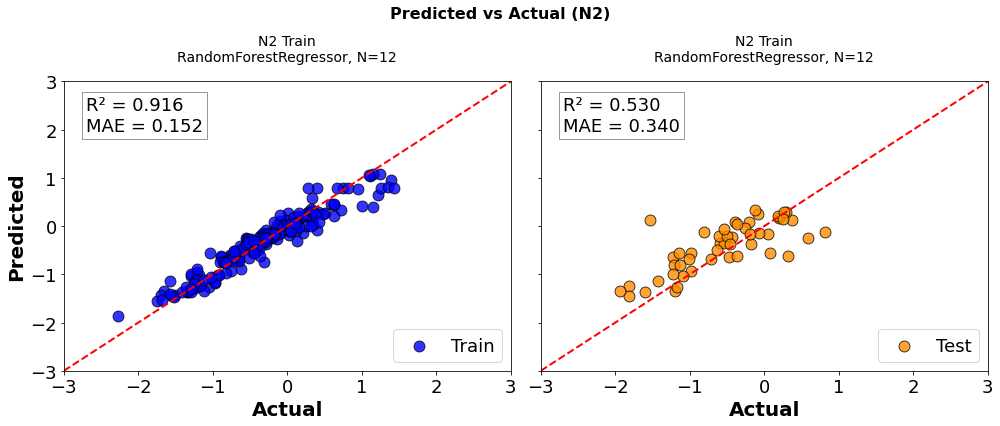

In [56]:
plot_pred_vs_actual(tuned_res_N2_noOutlier, title_prefix="N2", first_set="trainval",fixed_lims=[-3, 3])


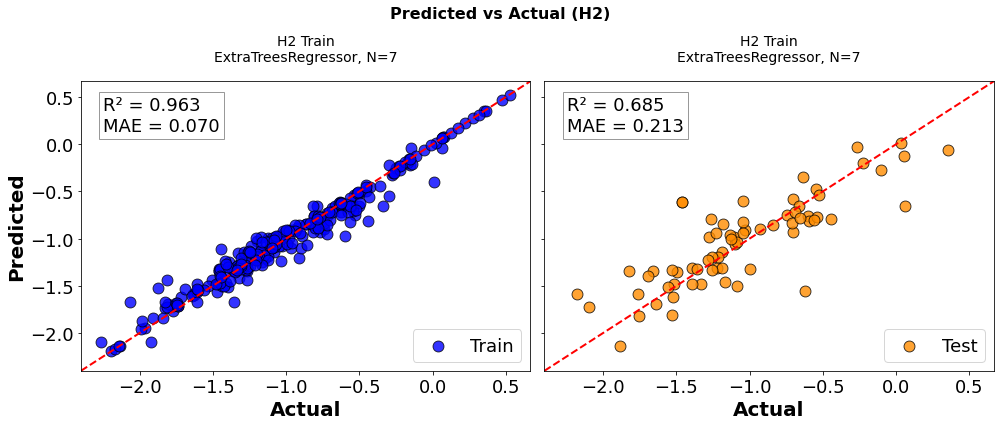

In [57]:
plot_pred_vs_actual(tuned_res_H2_noOutlier, title_prefix="H2", first_set="trainval",fixed_lims=None)


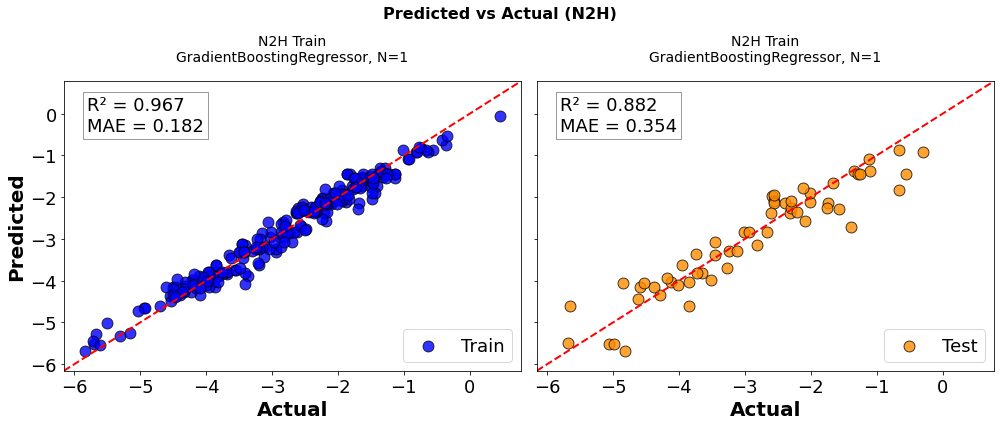

In [58]:
plot_pred_vs_actual(tuned_res_N2H_noOutlier, title_prefix="N2H", first_set="trainval",fixed_lims=None)


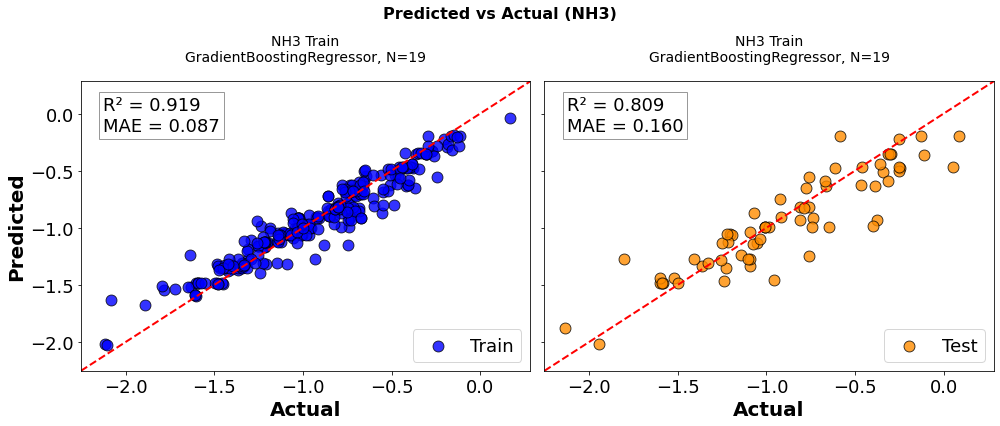

In [59]:
plot_pred_vs_actual(tuned_res_NH3_noOutlier, title_prefix="NH3", first_set="trainval",fixed_lims=None)


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Abbreviation dictionary
MODEL_ABBR = {
    "LinearRegression": "LinReg",
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "ElasticNet": "ENet",
    "HuberRegressor": "Huber",
    "DecisionTreeRegressor": "DT",
    "RandomForestRegressor": "RF",
    "GradientBoostingRegressor": "GB",
    "ExtraTreesRegressor": "ET",
    "SVR": "SVR",
    "KernelRidge": "KR",
    "KNeighborsRegressor": "KNN",
    "MLPRegressor": "MLP",
    "XGBRegressor": "XGB",
    "TabPFNRegressor": "TabPFN",
}

def plot_top_models_metrics(res, mol_name=None,top_k=3, exclude_models=("TabPFNRegressor","MLPRegressor")):
    """
    Plot MAE, RMSE, and R² of top models at the best neighbor 'n',
    ranked by lowest validation MAE. Values are annotated above bars.
    Uses abbreviations for model names.
    """
    # 1. Extract best neighbor 'n'
    best_n, _, _ = res["best_on_val"]

    # 2. Get validation results for that n
    val_results_n = res["val_results"][best_n]

    # 3. Convert to DataFrame
    rows = []
    for model_name, metrics in val_results_n.items():
        if "r2" in metrics and model_name not in exclude_models:
            rows.append({
                "model": MODEL_ABBR.get(model_name, model_name),  # abbreviation
                "R2": metrics["r2"],
                "RMSE": metrics["rmse"],
                "MAE": metrics["mae"],
            })
    df = pd.DataFrame(rows)

    # 4. Sort by val_mae (ascending, lower is better)
    df_top = df.sort_values("MAE", ascending=True).head(top_k)

    # 5. Melt for seaborn barplot
    df_melt = df_top.melt(
        id_vars="model", 
        value_vars=["MAE", "RMSE", "R2"],
        var_name="Metric", 
        value_name="Value"
    )

    # Metric color mapping
    palette = {
        "MAE": "red",
        "RMSE": "green",
        "R2": "pink"
    }

    # === PLOT ===
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_melt, x="model", y="Value", hue="Metric",
        palette=palette, width=0.6,  # 🔹 narrower bars (default is 0.8)
        edgecolor="black", linewidth=1.2  # 🔹 frame around bars
    )

    # Add value labels above bars (skip near-zero)
    for p in ax.patches:
        height = p.get_height()
        if height > 1e-6:  # skip zeros
            ax.annotate(
                f"{height:.3f}",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom",
                fontsize=13, weight="bold"
            )
    plt.ylim(0,1)
    plt.title(f"Top {top_k} Models at n={best_n} (Val set)", fontsize=14, weight="bold",pad=20)
    plt.xlabel("Model", fontsize=20, weight="bold")
    plt.ylabel("Metric Value (val)", fontsize=20, weight="bold")
    plt.xticks(rotation=0, ha="center", fontsize=17)
    plt.yticks(fontsize=17)

    # Remove extra baseline ticks
    ax.tick_params(axis="x", bottom=False)

    plt.legend(fontsize=15,)
    plt.tight_layout()
    plt.savefig(f"paper_files/{mol_name}_top{top_k}_bestModel_adsorbdOnly.pdf", dpi=600, bbox_inches="tight")
    plt.show()


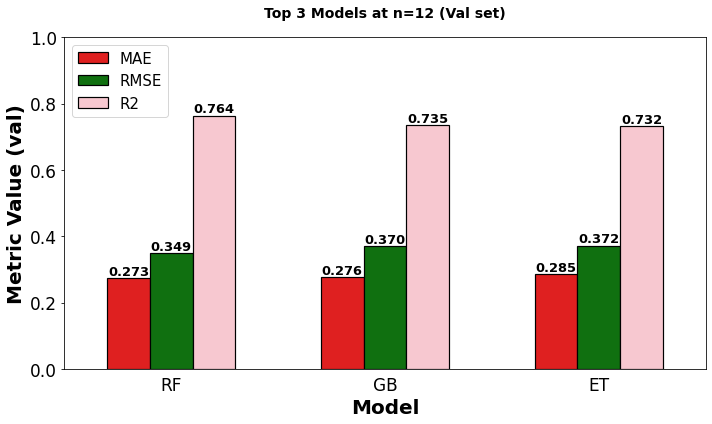

In [49]:
plot_top_models_metrics(res_N2_noOutlier, mol_name='N2',top_k=3)

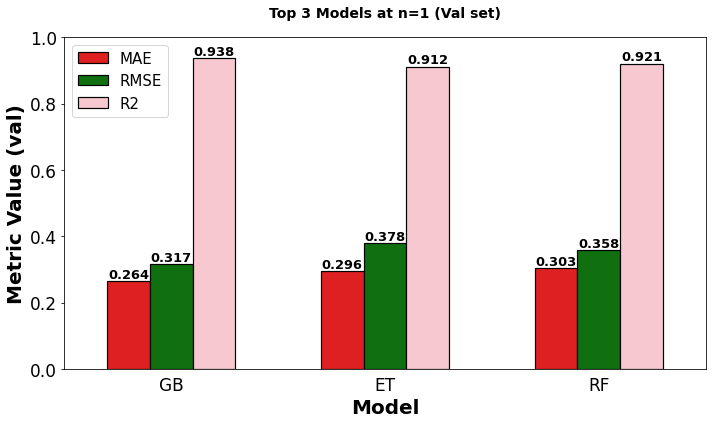

In [34]:
plot_top_models_metrics(res_N2H_noOutlier, mol_name='N2H',top_k=3)

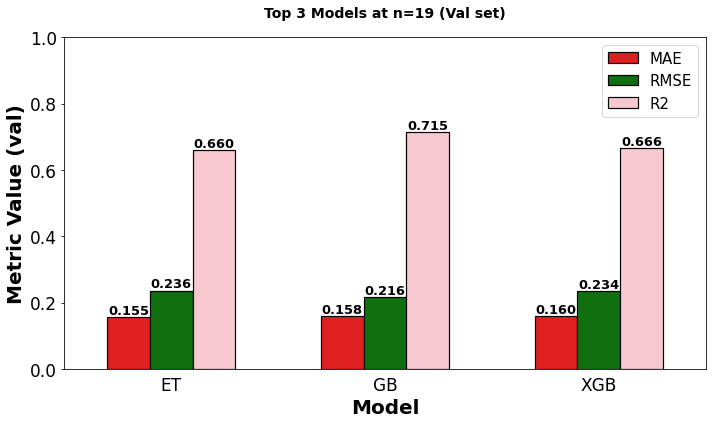

In [35]:
plot_top_models_metrics(res_NH3_noOutlier, mol_name='NH3',top_k=3)

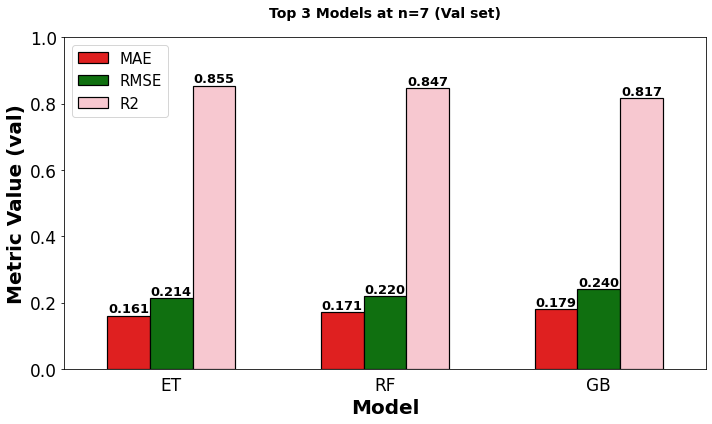

In [36]:
plot_top_models_metrics(res_H2_noOutlier, mol_name="H2",top_k=3)

In [37]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

# === Renaming helper with subscripts ===
def shorten_feature_name(colname: str) -> str:
    """
    Shorten verbose feature names into compact scientific notation
    with LaTeX-style subscripts for orbitals and (local/total).
    """
    prop_map = {
        "electroneg": "X",
        "elect_affinity": "EA",
        "atomic_radius": "r",
        "cov_rad": "rc",
        "atom_density": "ρ",
        "charge": "q",
    }

    # Weighted averages (WA)
    if colname.startswith("wavg_"):
        for prop, symbol in prop_map.items():
            if f"_{prop}_" in colname:
                return f"$WA_{{{symbol},local}}$"

    # Simple averages (A)
    if colname.startswith("avg_"):
        for prop, symbol in prop_map.items():
            if f"_{prop}_" in colname:
                return f"$A_{{{symbol},local}}$"

    # DOS features
    if "dos" in colname:
        parts = colname.split("_")
        sel = parts[3]      # "selected" or "total"
        band = parts[4][0]  # "s", "p", "d"
        stat = parts[-1]    # "center" or "sum"

        if sel == "selected" and stat == "center":
            return f"$ε_{{{band},local}}$"
        if sel == "total" and stat == "center":
            return f"$ε_{{{band}}}$"
        if sel == "selected" and stat == "sum":
            return f"$f_{{{band},local}}$"
        if sel == "total" and stat == "sum":
            return f"$f_{{{band},total}}$"

    return colname


def explain_with_shap(
    tuned_res,
    nsample=200,
    background_size=100,
    molname="molecule",
    save_path='./paper_files/'
):
    """
    Explain model predictions with SHAP (bar summary plot only).
    """
    best_pipe = tuned_res["best_pipeline"]
    model = best_pipe.named_steps["model"]
    X = tuned_res["X_trainval"]

    # Subsample for efficiency
    X_sample = X.sample(min(nsample, len(X)), random_state=42)
    # Apply renaming
    rename_map = {c: shorten_feature_name(c) for c in X_sample.columns}
    X_sample = X_sample.rename(columns=rename_map)

    # ---- Choose explainer ----
    if isinstance(model, (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, DecisionTreeRegressor, XGBRegressor)):
        print("✅ Using TreeExplainer for tree-based model")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    elif isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor)):
        print("✅ Using LinearExplainer for linear model")
        explainer = shap.LinearExplainer(model, X)
        shap_values = explainer.shap_values(X_sample)
    else:
        print("⚠️ Using KernelExplainer (slow) for model type:", type(model).__name__)
        X_background = shap.sample(X, min(background_size, len(X)), random_state=42)
        explainer = shap.KernelExplainer(model.predict, X_background)
        shap_values = explainer.shap_values(X_sample)

    # ---- Plot (bar only, customized) ----
    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, color="green")

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ax = plt.gca()

    # --- Add frame around the entire graph ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    # Ensure x-axis has some right padding
    xmax = max(mean_abs_shap) * 1.15   # 15% padding
    ax.set_xlim(0, xmax)

    bars = ax.patches

    # 🔥 Fix annotation mismatch: SHAP sorts bars top→bottom, patches are bottom→top
    order = np.argsort(mean_abs_shap)[::-1]
    mean_abs_sorted = mean_abs_shap[order]
    values_for_display = mean_abs_sorted[::-1][:len(bars)]  # reverse to align with patch order

    for bar, value in zip(bars, values_for_display):
        ax.text(
            bar.get_width() + 0.02 * xmax,  # offset annotation
            bar.get_y() + bar.get_height()/2,
            f"{value:.3f}",
            va='center', ha='left', fontsize=12
        )
        bar.set_edgecolor("black")   # add frame
        bar.set_linewidth(0.8)

    # Style ticks and labels
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlabel("SHAP value (average impact on model output magnitude)", fontsize=16,fontweight='bold')

    # --- Title with actual explained model + n ---
    explained_model_name = model.__class__.__name__
    best_n = tuned_res['best_n']

    title_str = f"Feature Importance — {molname} | Model: {explained_model_name} | n={best_n}"
    plt.title(title_str, fontsize=16, pad=25)

    plt.tight_layout()

    if save_path:
        plt.savefig(f"{save_path}/{molname}_SHAP_adsorbdOnly.pdf", dpi=600, bbox_inches="tight")
        print("💾 Plot saved")

    plt.show()

    return explainer, shap_values


✅ Using TreeExplainer for tree-based model
💾 Plot saved


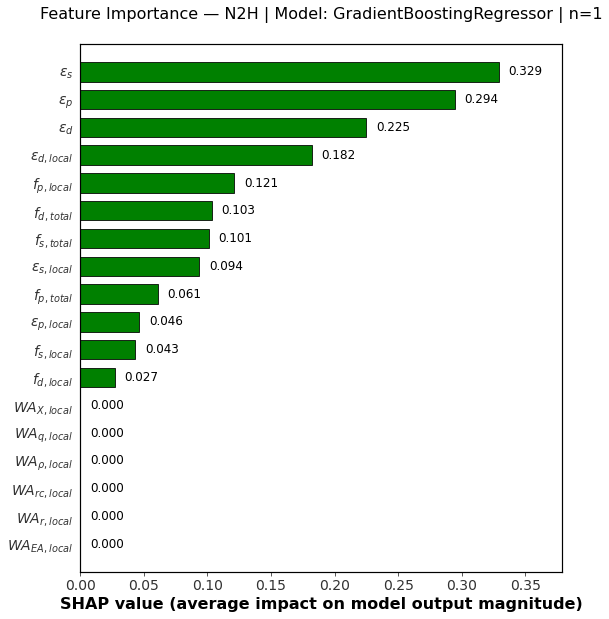

(<shap.explainers._tree.TreeExplainer at 0x7f72e172b1c0>,
 array([[ 0.        ,  0.        ,  0.        , ..., -0.00429816,
         -0.0990507 , -0.12432736],
        [ 0.        ,  0.        ,  0.        , ...,  0.00504161,
         -0.08836571, -0.13532242],
        [ 0.        ,  0.        ,  0.        , ..., -0.02321513,
         -0.37199012,  0.04524166],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., -0.02218848,
         -0.42306866, -0.15384785],
        [ 0.        ,  0.        ,  0.        , ...,  0.01530144,
         -0.39366073, -0.15383213],
        [ 0.        ,  0.        ,  0.        , ..., -0.01632799,
         -0.24512922, -0.12059377]]))

In [38]:
explain_with_shap(tuned_res_N2H_noOutlier,molname='N2H')

✅ Using TreeExplainer for tree-based model
💾 Plot saved


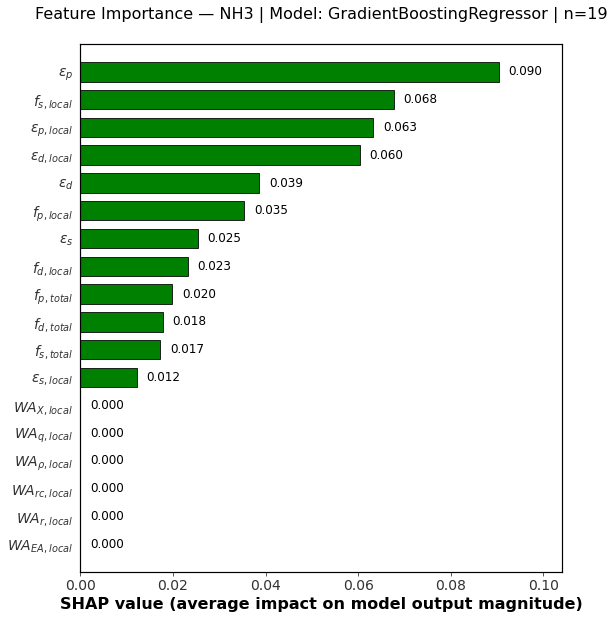

(<shap.explainers._tree.TreeExplainer at 0x7f729a7a87f0>,
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.53110080e-04,  1.17908838e-04,  1.28781184e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          6.47923768e-02,  1.38114485e-01,  1.95658831e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.13970532e-02,  9.69750818e-03, -2.35430894e-02],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -5.98922928e-04,  5.90711275e-03,  1.17945257e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.35758779e-02, -4.49080319e-03, -8.24104129e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          2.35631194e-02, -1.14147549e-02,  1.06859863e-02]]))

In [19]:
explain_with_shap(tuned_res_NH3_noOutlier,molname='NH3')

✅ Using TreeExplainer for tree-based model
💾 Plot saved


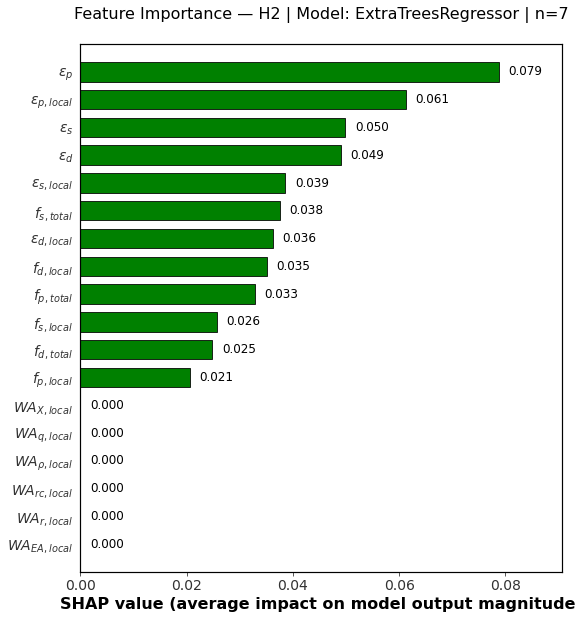

(<shap.explainers._tree.TreeExplainer at 0x7f729a565520>,
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -2.66774070e-02, -2.94107959e-02,  2.41337814e-04],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.99584848e-02, -1.51548489e-02,  1.58080567e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          4.79362248e-03,  4.31656337e-03, -9.75192904e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          8.54810087e-02,  3.01729046e-01,  6.63018026e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.10094563e-01,  2.41195969e-01, -7.54665745e-03],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.13579059e-02, -1.00162965e-02,  2.38271613e-02]]))

In [20]:
explain_with_shap(tuned_res_H2_noOutlier,molname='H2')

✅ Using TreeExplainer for tree-based model
💾 Plot saved


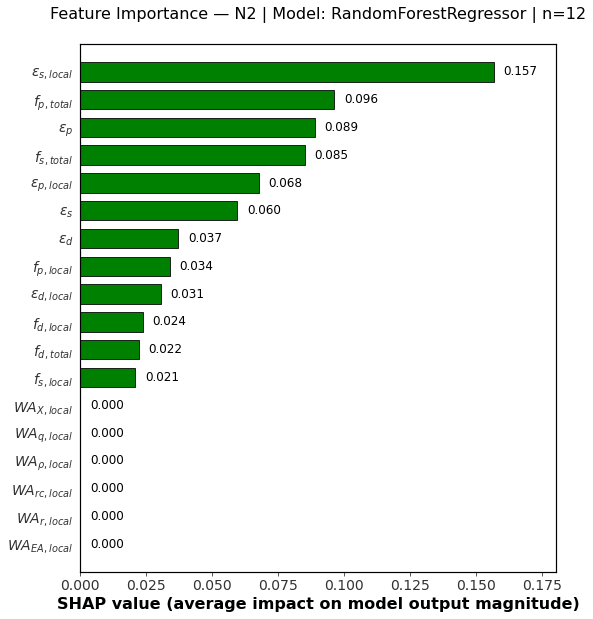

(<shap.explainers._tree.TreeExplainer at 0x7f729bb0d550>,
 array([[ 0.        ,  0.        ,  0.        , ...,  0.01574095,
          0.02206624, -0.01914138],
        [ 0.        ,  0.        ,  0.        , ...,  0.02791123,
          0.07229945,  0.05360161],
        [ 0.        ,  0.        ,  0.        , ..., -0.02183342,
         -0.03435293, -0.05322943],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.01081178,
          0.07471697,  0.01078598],
        [ 0.        ,  0.        ,  0.        , ..., -0.00845999,
         -0.09648037, -0.02162019],
        [ 0.        ,  0.        ,  0.        , ...,  0.01874238,
          0.06220672,  0.02329863]]))

In [21]:
explain_with_shap(tuned_res_N2_noOutlier,molname='N2')

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Map full model names to short abbreviations
MODEL_ABBR = {
    "LinearRegression": "LR",
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "ElasticNet": "EN",
    "HuberRegressor": "Huber",
    "DecisionTreeRegressor": "DT",
    "RandomForestRegressor": "RF",
    "GradientBoostingRegressor": "GB",
    "ExtraTreesRegressor": "ET",
    "SVR": "SVR",
    "KernelRidge": "KR",
    "KNeighborsRegressor": "KNN",
    "MLPRegressor": "MLP",
    "XGBRegressor": "XGB",
    "TabPFNRegressor": "TabPFN",
}

def plot_best_per_n(results, 
                    n_min=0, 
                    n_max=20, 
                    exclude_models=None, 
                    molname="molecule",
                    save_path='./paper_files/'):
    """
    Plot R² and MAE across n for the best model at each n.
    """
    if exclude_models is None:
        exclude_models = []

    ns = []
    r2_vals = []
    mae_vals = []
    models_used = []

    # For each n, find best model (respect exclusions)
    for n in range(n_min, n_max+1):
        if n not in results["val_results"]:
            continue
        mres = results["val_results"][n]

        best_name, best_r2, best_mae = None, -np.inf, np.inf
        for name, metrics in mres.items():
            if name in exclude_models:
                continue
            if "r2" not in metrics:
                continue
            r2v, maev = metrics["r2"], metrics["mae"]
            if (r2v > best_r2) or (abs(r2v - best_r2) < 1e-6 and maev < best_mae):
                best_name, best_r2, best_mae = name, r2v, maev

        if best_name:
            ns.append(n+1)  # shift: 0→1, 1→2, ...
            r2_vals.append(best_r2)
            mae_vals.append(best_mae)
            models_used.append(MODEL_ABBR.get(best_name, best_name))

    # --- Plot R² ---
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(ns, r2_vals, marker="o", color="blue")
    for i, (x,y,m) in enumerate(zip(ns, r2_vals, models_used)):
        offset = 0.12 * (max(r2_vals) - min(r2_vals))
        if i % 2 == 0:
            ax.text(x, y + offset, m, ha="center", va="bottom", fontsize=12)  # above
        else:
            ax.text(x, y - offset, m, ha="center", va="top", fontsize=12)     # below
    
    ax.set_xlabel("Number of neighbors", fontsize=18,fontweight='bold')
    ax.set_ylabel("R² (val)", fontsize=18,fontweight='bold')
    ax.set_title(f"Best Model R² vs Neighbors — {molname}", fontsize=14,pad=25)
    ax.grid(True)

    ax.set_xticks(range(1, n_max+2,1))  # force ticks 1..21
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))  

    ax.set_ylim(min(r2_vals) - 0.1, max(r2_vals) + 0.1)
    ax.tick_params(axis="both", labelsize=14)  # tick font size

    plt.tight_layout()
    plt.savefig(f"{save_path}/{molname}_cvR2VSneighbor_adsorbedonly_nooutlier.pdf", dpi=600, bbox_inches="tight")
    plt.show()

    # --- Plot MAE ---
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(ns, mae_vals, marker="o", color="red")
    for i, (x,y,m) in enumerate(zip(ns, mae_vals, models_used)):
        offset = 0.12 * (max(mae_vals) - min(mae_vals))
        if i % 2 == 0:
            ax.text(x, y + offset, m, ha="center", va="bottom", fontsize=12)  # above
        else:
            ax.text(x, y - offset, m, ha="center", va="top", fontsize=12)     # below
    ax.set_xlabel("Number of neighbors", fontsize=18,fontweight='bold')
    ax.set_ylabel("MAE (val)", fontsize=18,fontweight='bold')
    ax.set_title(f"Best Model MAE vs Neighbors — {molname}", fontsize=14,pad=25)
    ax.grid(True)

    ax.set_xticks(range(1, n_max+2,1))  # force ticks 1..21
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))  

    ax.set_ylim(min(mae_vals) - 0.1, max(mae_vals) + 0.1)
    ax.tick_params(axis="both", labelsize=14)  # tick font size


    plt.tight_layout()
    plt.savefig(f"{save_path}/{molname}_cvMAEVSneighbor_adsorbedonly_nooutlier.pdf", dpi=600, bbox_inches="tight")
    plt.show()


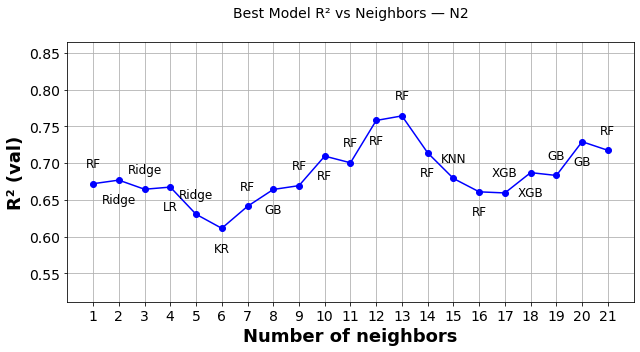

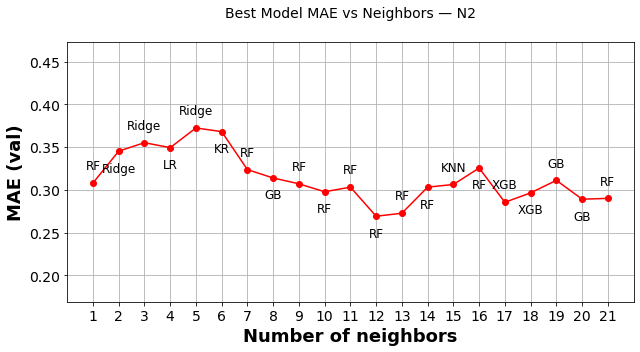

In [28]:
plot_best_per_n(res_N2_noOutlier, n_min=0, n_max=20, 
                exclude_models=["TabPFNRegressor",'MLPRegressor'], 
                molname="N2")

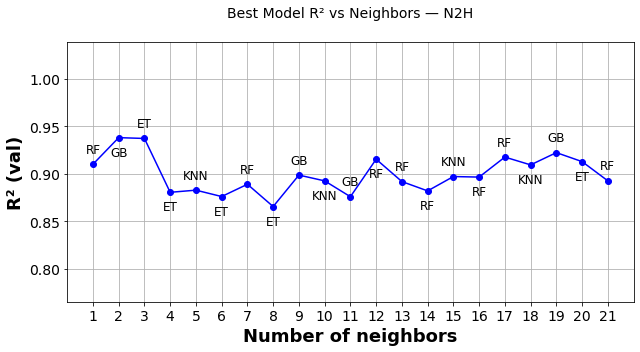

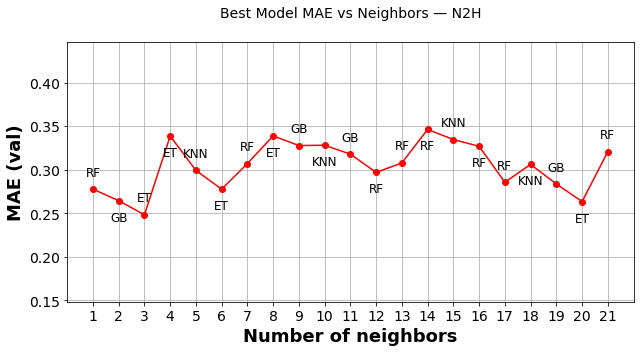

In [29]:
plot_best_per_n(res_N2H_noOutlier, n_min=0, n_max=20, 
                exclude_models=["TabPFNRegressor",'MLPRegressor'], 
                molname="N2H")

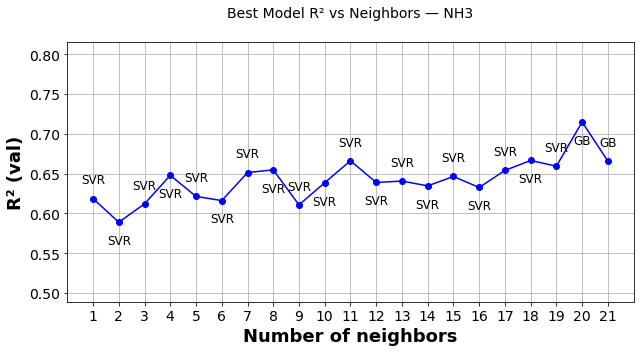

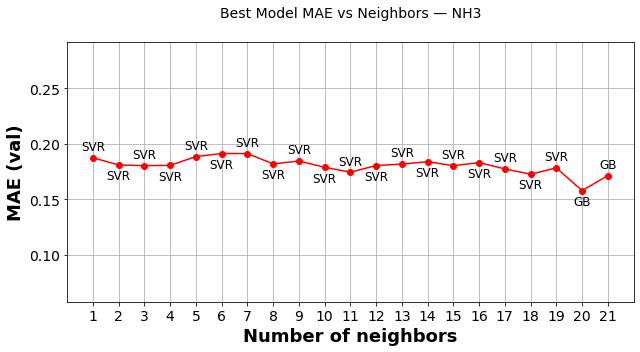

In [30]:
plot_best_per_n(res_NH3_noOutlier, n_min=0, n_max=20, 
                exclude_models=["TabPFNRegressor",'MLPRegressor'], 
                molname="NH3")

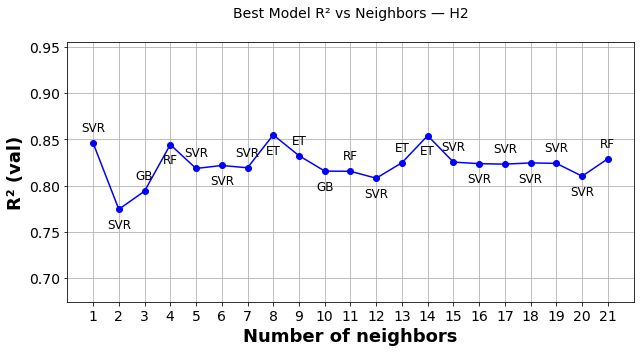

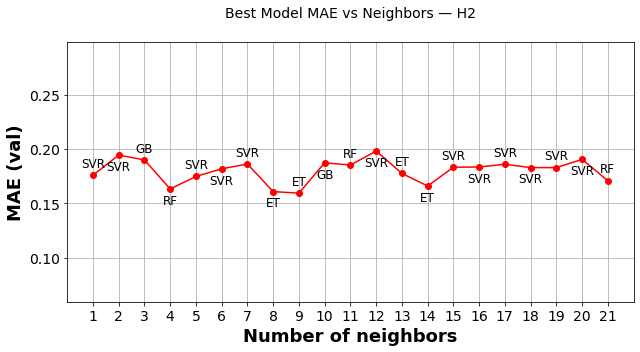

In [31]:
plot_best_per_n(res_H2_noOutlier, n_min=0, n_max=20, 
                exclude_models=["TabPFNRegressor",'MLPRegressor'], 
                molname="H2")

In [69]:

tuned_results = {
    "N2": tuned_res_N2_noOutlier,
    "N2H": tuned_res_N2H_noOutlier,
    "NH3": tuned_res_NH3_noOutlier,
    "H2": tuned_res_H2_noOutlier,
}

rows = []
for mol, res in tuned_results.items():
    rows.append({
        "Molecule": mol,
        "Best Model": res["best_model_name"],
        "Best Params": res["best_params"]
    })

df_best_params = pd.DataFrame(rows)


df_best_params.to_csv('./paper_files/best_parameters.csv')



In [139]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

# === Renaming helper with subscripts ===
def shorten_feature_name(colname: str) -> str:
    """
    Shorten verbose feature names into compact scientific notation
    with LaTeX-style subscripts for orbitals and (local/total).
    """
    prop_map = {
        "electroneg": "X",
        "elect_affinity": "EA",
        "atomic_radius": "r",
        "cov_rad": "rc",
        "atom_density": "ρ",
        "charge": "q",
    }

    # Weighted averages (WA)
    if colname.startswith("wavg_"):
        for prop, symbol in prop_map.items():
            if f"_{prop}_" in colname:
                return f"$WA_{{{symbol},local}}$"

    # Simple averages (A)
    if colname.startswith("avg_"):
        for prop, symbol in prop_map.items():
            if f"_{prop}_" in colname:
                return f"$A_{{{symbol},local}}$"

    # DOS features
    if "dos" in colname:
        parts = colname.split("_")
        sel = parts[3]      # "selected" or "total"
        band = parts[4][0]  # "s", "p", "d"
        stat = parts[-1]    # "center" or "sum"

        if sel == "selected" and stat == "center":
            return f"$ε_{{{band},local}}$"
        if sel == "total" and stat == "center":
            return f"$ε_{{{band}}}$"
        if sel == "selected" and stat == "sum":
            return f"$f_{{{band},local}}$"
        if sel == "total" and stat == "sum":
            return f"$f_{{{band},total}}$"

    return colname


def explain_with_shap(
    tuned_res,
    nsample=200,
    background_size=100,
    molname="molecule",
    save_path='./paper_files/'
):
    """
    Explain model predictions with SHAP.
    Produces:
      - Bar summary plot (mean |SHAP| importance)
      - Beeswarm plot (direction + importance) with frame,
        filtering out features with zero mean |SHAP|.
    """
    best_pipe = tuned_res["best_pipeline"]
    model = best_pipe.named_steps["model"]
    X = tuned_res["X_trainval"]

    # Subsample for efficiency
    X_sample = X.sample(min(nsample, len(X)), random_state=42)
    # Apply renaming
    rename_map = {c: shorten_feature_name(c) for c in X_sample.columns}
    X_sample = X_sample.rename(columns=rename_map)

    # ---- Choose explainer ----
    if isinstance(model, (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, DecisionTreeRegressor, XGBRegressor)):
        print("✅ Using TreeExplainer for tree-based model")
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    elif isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor)):
        print("✅ Using LinearExplainer for linear model")
        explainer = shap.LinearExplainer(model, X)
        shap_values = explainer.shap_values(X_sample)
    else:
        print("⚠️ Using KernelExplainer (slow) for model type:", type(model).__name__)
        X_background = shap.sample(X, min(background_size, len(X)), random_state=42)
        explainer = shap.KernelExplainer(model.predict, X_background)
        shap_values = explainer.shap_values(X_sample)

    # ---- Plot 1: Bar summary plot ----
    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, color="green")

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ax = plt.gca()

    # --- Add frame around the entire graph ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    xmax = max(mean_abs_shap) * 1.15   # 15% padding
    ax.set_xlim(0, xmax)

    bars = ax.patches
    order = np.argsort(mean_abs_shap)[::-1]
    mean_abs_sorted = mean_abs_shap[order]
    values_for_display = mean_abs_sorted[::-1][:len(bars)]  # reverse to align with patch order

    for bar, value in zip(bars, values_for_display):
        ax.text(
            bar.get_width() + 0.02 * xmax,
            bar.get_y() + bar.get_height()/2,
            f"{value:.3f}",
            va='center', ha='left', fontsize=12
        )
        bar.set_edgecolor("black")
        bar.set_linewidth(0.8)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlabel("SHAP value (average impact on model output magnitude)", fontsize=16, fontweight='bold')

    explained_model_name = model.__class__.__name__
    best_n = tuned_res['best_n']
    title_str = f"Feature Importance — {molname} | Model: {explained_model_name} | n={best_n}"
    plt.title(title_str, fontsize=16, pad=25)
    plt.tight_layout()

    plt.show()

    # ---- Filter out features with zero mean(|SHAP|) before beeswarm ----
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    nonzero_idx = mean_abs_shap > 1e-12  # threshold
    shap_values_filtered = shap_values[:, nonzero_idx]
    X_filtered = X_sample.loc[:, nonzero_idx]

    # ---- Plot 2: SHAP Beeswarm (value direction effect) ----
    plt.figure()
    shap.summary_plot(shap_values_filtered, X_filtered, plot_type="dot", show=False, color_bar=True, color="coolwarm")

    ax = plt.gca()
    # --- Add frame around the beeswarm plot ---
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)
    yticks = ax.get_yticklabels()
    for tick in yticks:
        tick.set_horizontalalignment("right")
        tick.set_x(0.04)
    
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=20)
    
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=16, fontweight='bold')

    plt.title(f"SHAP Beeswarm — {molname} | Model: {explained_model_name} | n={best_n}", fontsize=16, pad=25)
    plt.tight_layout()

    if save_path:
        plt.savefig(f"{save_path}/{molname}_SHAP_beeswarm.pdf", dpi=600, bbox_inches="tight")
        print("💾 Beeswarm plot saved")
    
    plt.show()

    return explainer, shap_values


✅ Using TreeExplainer for tree-based model


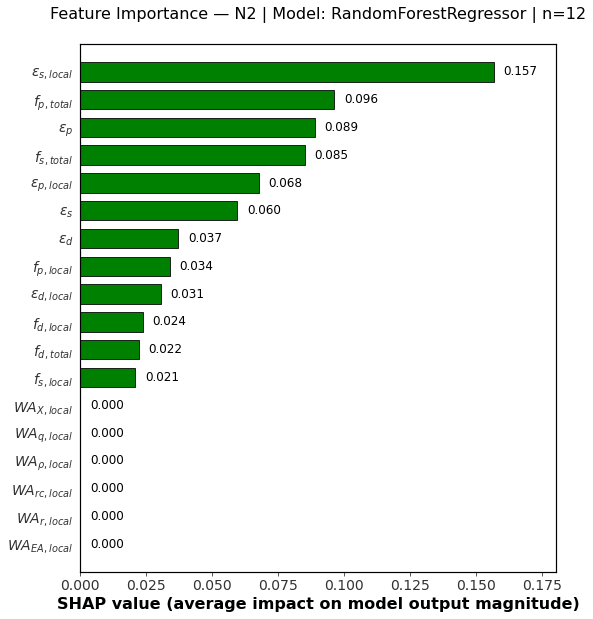

💾 Beeswarm plot saved


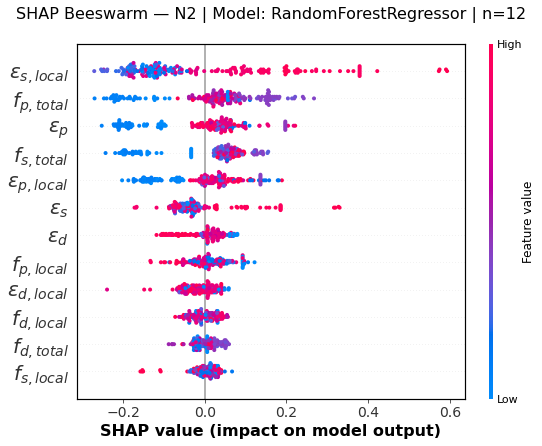

(<shap.explainers._tree.TreeExplainer at 0x7f7190077d60>,
 array([[ 0.        ,  0.        ,  0.        , ...,  0.01574095,
          0.02206624, -0.01914138],
        [ 0.        ,  0.        ,  0.        , ...,  0.02791123,
          0.07229945,  0.05360161],
        [ 0.        ,  0.        ,  0.        , ..., -0.02183342,
         -0.03435293, -0.05322943],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.01081178,
          0.07471697,  0.01078598],
        [ 0.        ,  0.        ,  0.        , ..., -0.00845999,
         -0.09648037, -0.02162019],
        [ 0.        ,  0.        ,  0.        , ...,  0.01874238,
          0.06220672,  0.02329863]]))

In [140]:
explain_with_shap(tuned_res_N2_noOutlier,molname='N2')

✅ Using TreeExplainer for tree-based model


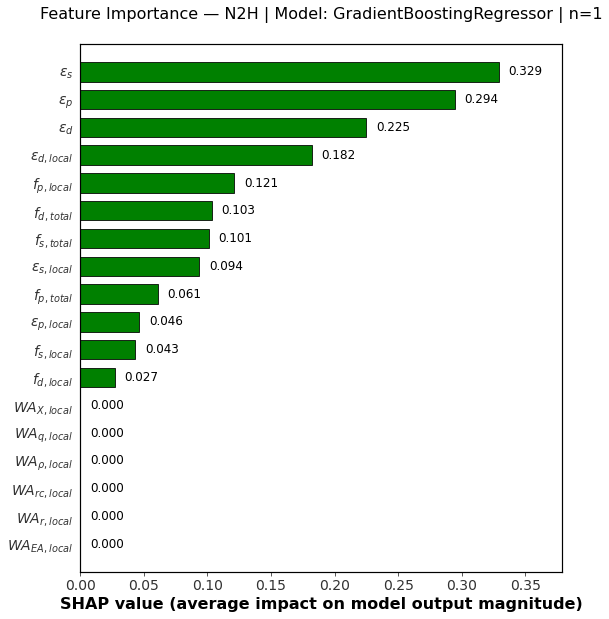

💾 Beeswarm plot saved


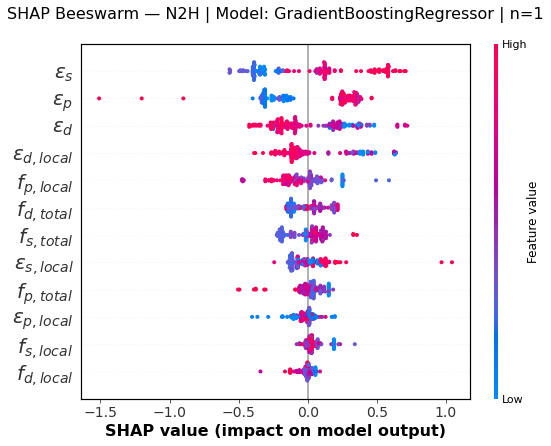

(<shap.explainers._tree.TreeExplainer at 0x7f7190711a30>,
 array([[ 0.        ,  0.        ,  0.        , ..., -0.00429816,
         -0.0990507 , -0.12432736],
        [ 0.        ,  0.        ,  0.        , ...,  0.00504161,
         -0.08836571, -0.13532242],
        [ 0.        ,  0.        ,  0.        , ..., -0.02321513,
         -0.37199012,  0.04524166],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., -0.02218848,
         -0.42306866, -0.15384785],
        [ 0.        ,  0.        ,  0.        , ...,  0.01530144,
         -0.39366073, -0.15383213],
        [ 0.        ,  0.        ,  0.        , ..., -0.01632799,
         -0.24512922, -0.12059377]]))

In [141]:
explain_with_shap(tuned_res_N2H_noOutlier,molname='N2H')

✅ Using TreeExplainer for tree-based model


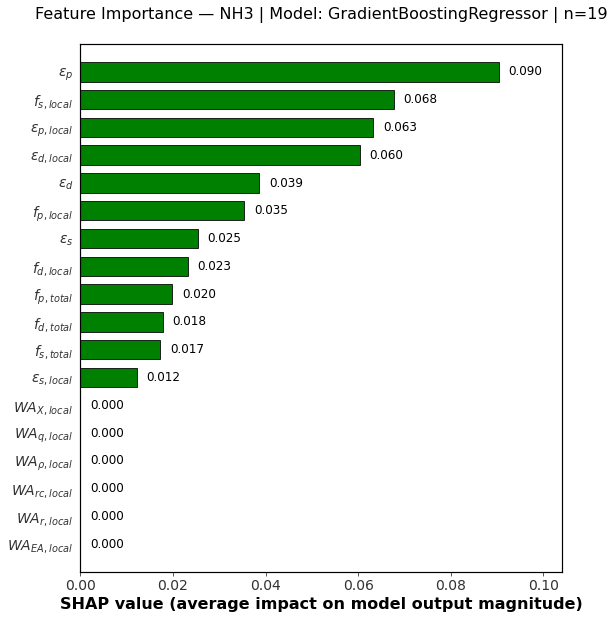

💾 Beeswarm plot saved


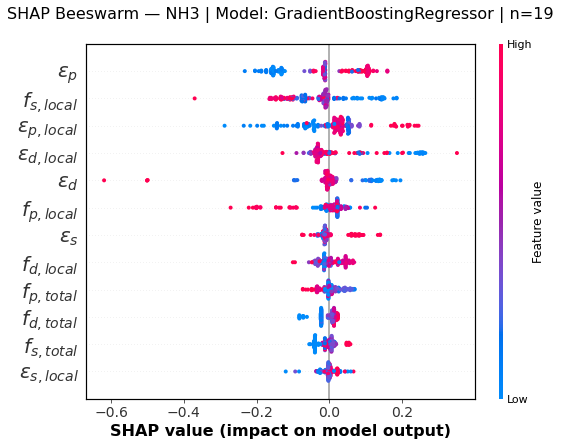

(<shap.explainers._tree.TreeExplainer at 0x7f7190077f70>,
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.53110080e-04,  1.17908838e-04,  1.28781184e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          6.47923768e-02,  1.38114485e-01,  1.95658831e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.13970532e-02,  9.69750818e-03, -2.35430894e-02],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -5.98922928e-04,  5.90711275e-03,  1.17945257e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.35758779e-02, -4.49080319e-03, -8.24104129e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          2.35631194e-02, -1.14147549e-02,  1.06859863e-02]]))

In [142]:
explain_with_shap(tuned_res_NH3_noOutlier,molname='NH3')

✅ Using TreeExplainer for tree-based model


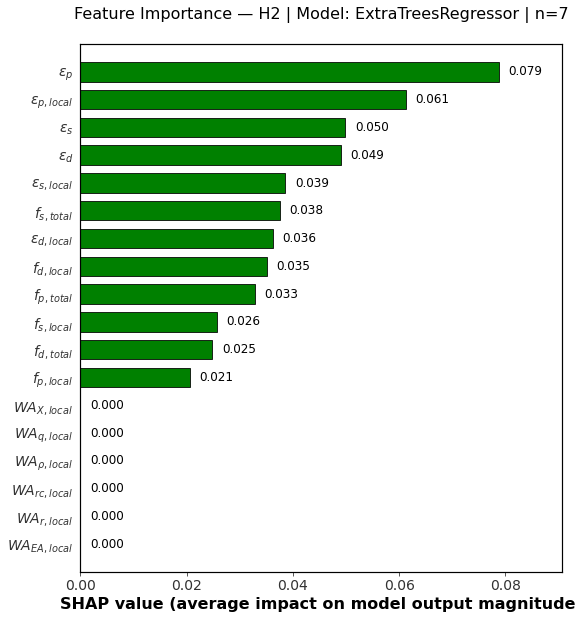

💾 Beeswarm plot saved


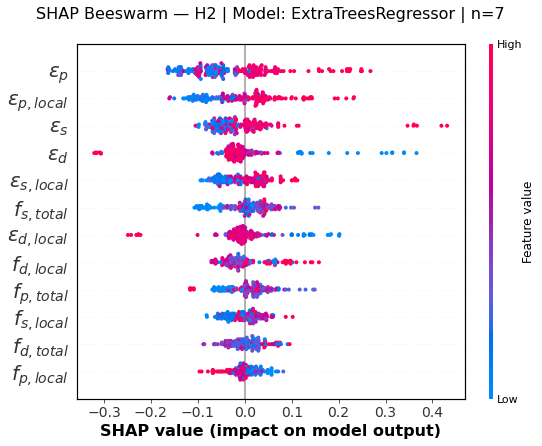

(<shap.explainers._tree.TreeExplainer at 0x7f729a8c17f0>,
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -2.66774070e-02, -2.94107959e-02,  2.41337814e-04],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.99584848e-02, -1.51548489e-02,  1.58080567e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          4.79362248e-03,  4.31656337e-03, -9.75192904e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          8.54810087e-02,  3.01729046e-01,  6.63018026e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.10094563e-01,  2.41195969e-01, -7.54665745e-03],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.13579059e-02, -1.00162965e-02,  2.38271613e-02]]))

In [143]:
explain_with_shap(tuned_res_H2_noOutlier,molname='H2')

In [164]:
df = df_N2_f
df[df["n0_n0_dos_total_dband_center"] > 0]

NameError: name 'df_N2_f' is not defined